# Temperature Conversion Workflow using LangGraph

This notebook demonstrates a simple LangGraph workflow to convert Celsius temperature to Fahrenheit.

In [26]:

%pip install -q langgraph langchain

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
from typing import TypedDict , NotRequired
from langgraph.graph import StateGraph, START, END

In [28]:
# Define the State Schema for the workflow using TypedDict
# State acts as a central memory object that is passed and updated across nodes in the graph
class TemperatureState(TypedDict):
    # Holds the input temperature in Celsius (float)
    temp_celsius: float
    # Holds the converted temperature result in Fahrenheit (float)
    temp_fahrenheit: NotRequired[float]

In [29]:
# Node Function: Receives the current State and returns a dictionary with updated state keys
def convert_temp(state: TemperatureState) -> dict:
    # Line 1: Extract the 'temp_celsius' value from the shared state dictionary
    celsius = state["temp_celsius"]
    
    # Line 2: Apply conversion math formula: Fahrenheit = (Celsius * 9/5) + 32
    fahrenheit = (celsius * 9 / 5) + 32
    
    # Line 3: Return updated state key-value pair; LangGraph automatically merges this into the main state
    return {"temp_fahrenheit": fahrenheit}

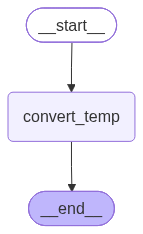

In [30]:
workflow = StateGraph(TemperatureState)
workflow.add_node('convert_temp', convert_temp)
workflow.add_edge(START, 'convert_temp')
workflow.add_edge('convert_temp', END)

app = workflow.compile()

In [ ]:
# Line 1: Define the starting state dictionary containing the initial Celsius value
initial_state = {"temp_celsius": 28.9}

# Line 2: Invoke the compiled workflow app with initial_state; executes from START -> convert_temp -> END
output = app.invoke(initial_state)

# Line 3: Print the initial input dictionary
print("Input State:", initial_state)

# Line 4: Print the final output state returned after all nodes finish executing
print("Output State:", output)